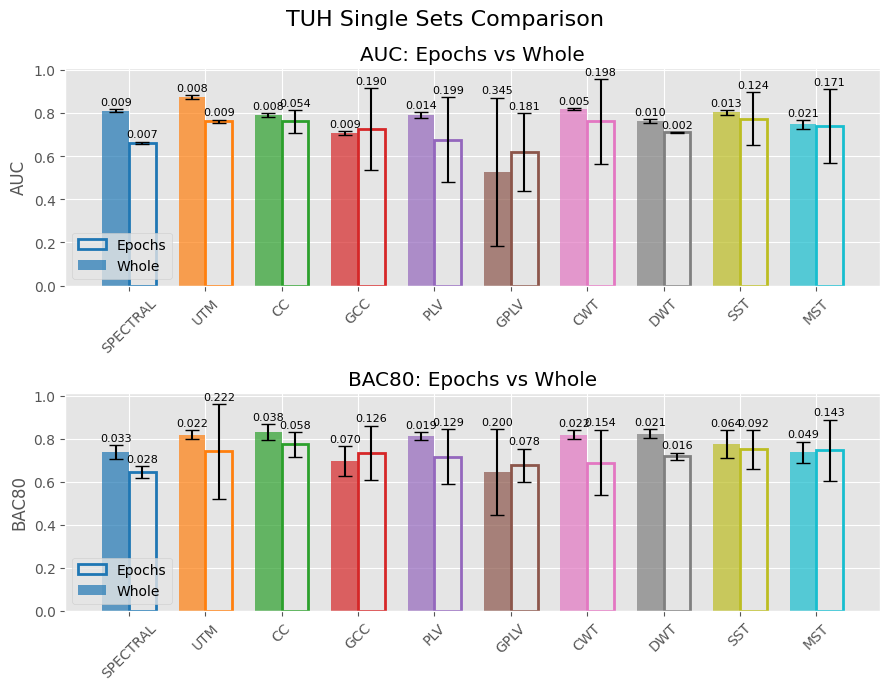

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#use ggplot style
plt.style.use('ggplot')

colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)
# TUH DATA SINGLE SET EPOCHED VERSION
data_epochs = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.66097, "AUC_STD": 0.0065279, "BAC80": 0.6453, "BAC80_STD": 0.027778},
    {"FEATURE_SET": "UTM", "AUC": 0.76068, "AUC_STD": 0.008547, "BAC80": 0.74145, "BAC80_STD": 0.22206},
    {"FEATURE_SET": "CC", "AUC": 0.76068, "AUC_STD": 0.053547, "BAC80": 0.77493, "BAC80_STD": 0.057824},
    {"FEATURE_SET": "GCC", "AUC": 0.72507, "AUC_STD": 0.19017, "BAC80": 0.73575, "BAC80_STD": 0.12555},
    {"FEATURE_SET": "PLV", "AUC": 0.67664, "AUC_STD": 0.19854, "BAC80": 0.71724, "BAC80_STD": 0.12858},
    {"FEATURE_SET": "GPLV", "AUC": 0.61823, "AUC_STD": 0.18057, "BAC80": 0.67664, "BAC80_STD": 0.078052},
    {"FEATURE_SET": "CWT", "AUC": 0.76068, "AUC_STD": 0.19845, "BAC80": 0.68946, "BAC80_STD": 0.15363},
    {"FEATURE_SET": "DWT", "AUC": 0.71083, "AUC_STD": 0.0024673, "BAC80": 0.71937, "BAC80_STD": 0.016038},
    {"FEATURE_SET": "SST", "AUC": 0.7735, "AUC_STD": 0.12364, "BAC80": 0.75071, "BAC80_STD": 0.09169},
    {"FEATURE_SET": "MST", "AUC": 0.73932, "AUC_STD": 0.17142, "BAC80": 0.74715, "BAC80_STD": 0.14254},
]

data_whole = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.811016144, "AUC_STD": 0.0087038, "BAC80": 0.738841406, "BAC80_STD": 0.032897},
    {"FEATURE_SET": "UTM", "AUC": 0.87464, "AUC_STD": 0.0075378, "BAC80": 0.81909, "BAC80_STD": 0.022206},
    {"FEATURE_SET": "CC", "AUC": 0.79107, "AUC_STD": 0.0082244, "BAC80": 0.83191, "BAC80_STD": 0.03846},
    {"FEATURE_SET": "GCC", "AUC": 0.7056, "AUC_STD": 0.0087038, "BAC80": 0.69468, "BAC80_STD": 0.07011},
    {"FEATURE_SET": "PLV", "AUC": 0.79107, "AUC_STD": 0.01434, "BAC80": 0.81292, "BAC80_STD": 0.019235},
    {"FEATURE_SET": "GPLV", "AUC": 0.52707, "AUC_STD": 0.34473, "BAC80": 0.64625, "BAC80_STD": 0.19992},
    {"FEATURE_SET": "CWT", "AUC": 0.81766, "AUC_STD": 0.0049346, "BAC80": 0.81861, "BAC80_STD": 0.021806},
    {"FEATURE_SET": "DWT", "AUC": 0.76353, "AUC_STD": 0.0098692, "BAC80": 0.82431, "BAC80_STD": 0.021383},
    {"FEATURE_SET": "SST", "AUC": 0.80247, "AUC_STD": 0.012847, "BAC80": 0.77493, "BAC80_STD": 0.06415},
    {"FEATURE_SET": "MST", "AUC": 0.74739, "AUC_STD": 0.021, "BAC80": 0.73789, "BAC80_STD": 0.048995},
]

df_epochs = pd.DataFrame(data_epochs)
df_whole = pd.DataFrame(data_whole)

# Set up grouped bar plot parameters
x = np.arange(len(df_epochs))
width = 0.35

# Plotting AUC comparison
plt.figure(figsize=(9, 7))
plt.subplot(211)
plt.suptitle('TUH Single Sets Comparison', fontsize=16)

bars1 = plt.bar(x + width/2, df_epochs["AUC"], width, yerr=df_epochs["AUC_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole["AUC"], width, yerr=df_whole["AUC_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=0.7, label='Whole')

plt.ylabel("AUC")
plt.title("AUC: Epochs vs Whole")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", #±
             ha='center', va='bottom', fontsize=8)

# Plotting BAC80 comparison
plt.subplot(212)
bars1 = plt.bar(x + width/2, df_epochs["BAC80"], width, yerr=df_epochs["BAC80_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole["BAC80"], width, yerr=df_whole["BAC80_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=0.7, label='Whole')

plt.ylabel("BAC80")
plt.title("BAC80: Epochs vs Whole")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## No IED data

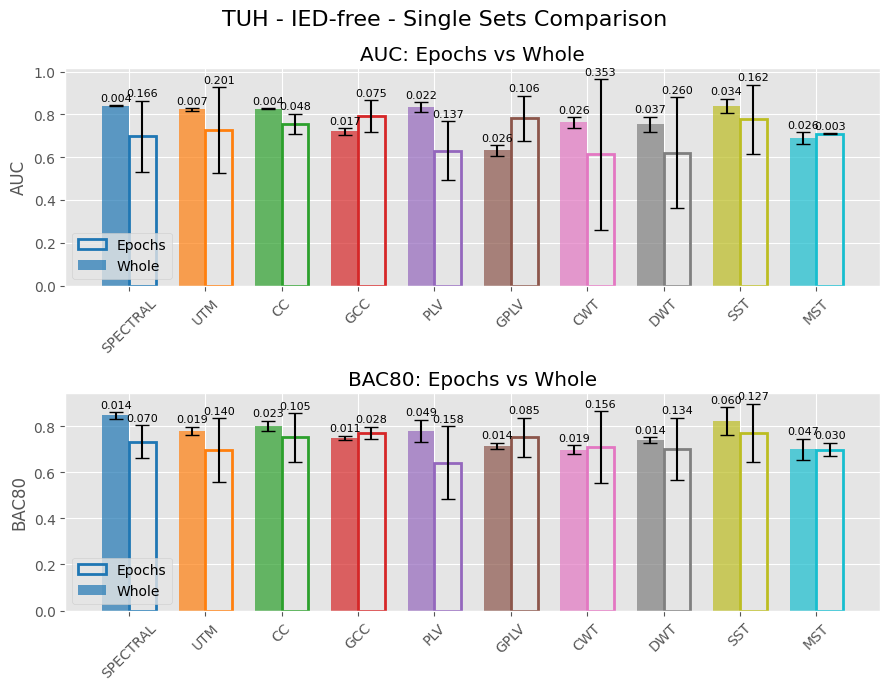

In [8]:
data_epochs_noied = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.69865, "AUC_STD": 0.16646, "BAC80": 0.733165, "BAC80_STD": 0.069906},
    {"FEATURE_SET": "UTM", "AUC": 0.72896, "AUC_STD": 0.20103, "BAC80": 0.696128, "BAC80_STD": 0.13981},
    {"FEATURE_SET": "CC", "AUC": 0.75589, "AUC_STD": 0.048002, "BAC80": 0.75168, "BAC80_STD": 0.10516},
    {"FEATURE_SET": "GCC", "AUC": 0.79125, "AUC_STD": 0.074968, "BAC80": 0.7702, "BAC80_STD": 0.027778},
    {"FEATURE_SET": "PLV", "AUC": 0.63131, "AUC_STD": 0.13748, "BAC80": 0.64057, "BAC80_STD": 0.15795},
    {"FEATURE_SET": "GPLV", "AUC": 0.78283, "AUC_STD": 0.10582, "BAC80": 0.75168, "BAC80_STD": 0.084863},
    {"FEATURE_SET": "CWT", "AUC": 0.61448, "AUC_STD": 0.35286, "BAC80": 0.70791, "BAC80_STD": 0.156},
    {"FEATURE_SET": "DWT", "AUC": 0.62121, "AUC_STD": 0.25984, "BAC80": 0.70202, "BAC80_STD": 0.13448},
    {"FEATURE_SET": "SST", "AUC": 0.77778, "AUC_STD": 0.16201, "BAC80": 0.7702, "BAC80_STD": 0.12729},
    {"FEATURE_SET": "MST", "AUC": 0.71044, "AUC_STD": 0.0029593, "BAC80": 0.69865, "BAC80_STD": 0.029593},
]

data_whole_noied = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.84175084, "AUC_STD": 0.00367, "BAC80": 0.84680135, "BAC80_STD": 0.01378},
    {"FEATURE_SET": "UTM", "AUC": 0.82379, "AUC_STD": 0.007009, "BAC80": 0.77946, "BAC80_STD": 0.018519},
    {"FEATURE_SET": "CC", "AUC": 0.82716, "AUC_STD": 0.003888, "BAC80": 0.80079, "BAC80_STD": 0.022857},
    {"FEATURE_SET": "GCC", "AUC": 0.72166, "AUC_STD": 0.016609, "BAC80": 0.74866, "BAC80_STD": 0.010692},
    {"FEATURE_SET": "PLV", "AUC": 0.83389, "AUC_STD": 0.022419, "BAC80": 0.77946, "BAC80_STD": 0.048995},
    {"FEATURE_SET": "GPLV", "AUC": 0.633, "AUC_STD": 0.025838, "BAC80": 0.71456, "BAC80_STD": 0.013899},
    {"FEATURE_SET": "CWT", "AUC": 0.76316, "AUC_STD": 0.026316, "BAC80": 0.69865, "BAC80_STD": 0.018519},
    {"FEATURE_SET": "DWT", "AUC": 0.75309, "AUC_STD": 0.036935, "BAC80": 0.73906, "BAC80_STD": 0.01378},
    {"FEATURE_SET": "SST", "AUC": 0.84063, "AUC_STD": 0.033726, "BAC80": 0.82267, "BAC80_STD": 0.059529},
    {"FEATURE_SET": "MST", "AUC": 0.69024, "AUC_STD": 0.026297, "BAC80": 0.69921, "BAC80_STD": 0.046604},
]


df_epochs_noied = pd.DataFrame(data_epochs_noied)
df_whole_noied = pd.DataFrame(data_whole_noied)

# Set up grouped bar plot parameters
x = np.arange(len(df_epochs))
width = 0.35

# Plotting AUC comparison
plt.figure(figsize=(9, 7))
plt.subplot(211)
plt.suptitle('TUH - IED-free - Single Sets Comparison', fontsize=16)

bars1 = plt.bar(x + width/2, df_epochs_noied["AUC"], width, yerr=df_epochs_noied["AUC_STD"], 
                capsize=5, color=colors[:len(df_epochs_noied)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs_noied)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole_noied["AUC"], width, yerr=df_whole_noied["AUC_STD"], 
                capsize=5, color=colors[:len(df_whole_noied)], alpha=0.7, label='Whole')

plt.ylabel("AUC")
plt.title("AUC: Epochs vs Whole")
plt.xticks(x, df_epochs_noied["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs_noied["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole_noied["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", #±
             ha='center', va='bottom', fontsize=8)

# Plotting BAC80 comparison
plt.subplot(212)
bars1 = plt.bar(x + width/2, df_epochs_noied["BAC80"], width, yerr=df_epochs_noied["BAC80_STD"], 
                capsize=5, color=colors[:len(df_epochs_noied)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs_noied)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole_noied["BAC80"], width, yerr=df_whole_noied["BAC80_STD"], 
                capsize=5, color=colors[:len(df_whole_noied)], alpha=0.7, label='Whole')

plt.ylabel("BAC80")
plt.title("BAC80: Epochs vs Whole")
plt.xticks(x, df_epochs_noied["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs_noied["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole_noied["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

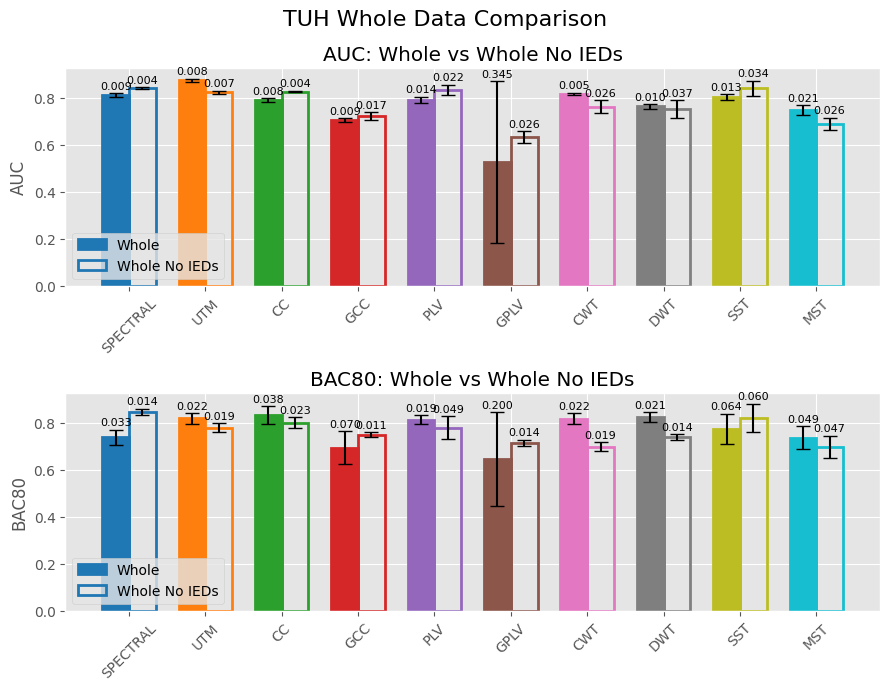

In [11]:
plt.figure(figsize=(9, 7))
plt.subplot(211)
plt.suptitle('TUH Whole Data Comparison', fontsize=16)

# Plot normal data (filled, left bar)
bars1 = plt.bar(x - width/2, df_whole["AUC"], width, yerr=df_whole["AUC_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=1, fill=True, 
                edgecolor=colors[:len(df_whole)], linewidth=2, label='Whole')

# Plot no IED data (unfilled, right bar)
bars2 = plt.bar(x + width/2, df_whole_noied["AUC"], width, yerr=df_whole_noied["AUC_STD"],
                capsize=5, color=colors[:len(df_whole_noied)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_whole_noied)], linewidth=2, label='Whole No IEDs')

plt.ylabel("AUC")
plt.title("AUC: Whole vs Whole No IEDs")
plt.xticks(x, df_whole["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for whole
for bar, std in zip(bars1, df_whole["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)
# Annotate std values above bars for whole no IEDs
for bar, std in zip(bars2, df_whole_noied["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Plotting BAC80 comparison
plt.subplot(212)
bars1 = plt.bar(x - width/2, df_whole["BAC80"], width, yerr=df_whole["BAC80_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=1, fill=True, 
                edgecolor=colors[:len(df_whole)], linewidth=2, label='Whole')
bars2 = plt.bar(x + width/2, df_whole_noied["BAC80"], width, yerr=df_whole_noied["BAC80_STD"],
                capsize=5, color=colors[:len(df_whole_noied)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_whole_noied)], linewidth=2, label='Whole No IEDs')

plt.ylabel("BAC80")
plt.title("BAC80: Whole vs Whole No IEDs")
plt.xticks(x, df_whole["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for whole
for bar, std in zip(bars1, df_whole["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)
# Annotate std values above bars for whole no IEDs
for bar, std in zip(bars2, df_whole_noied["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


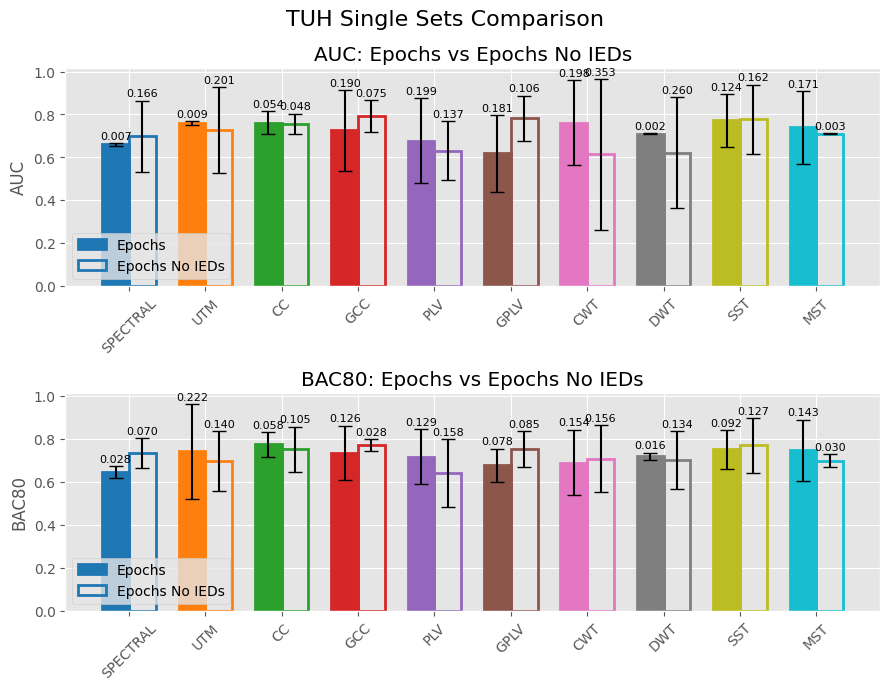

In [12]:
#do the same plots as the cell above but for the epochs data - with and without IEDs
plt.figure(figsize=(9, 7))
plt.subplot(211)
plt.suptitle('TUH Single Sets Comparison', fontsize=16)
# Plot normal data (filled, left bar)
bars1 = plt.bar(x - width/2, df_epochs["AUC"], width, yerr=df_epochs["AUC_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=True, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
# Plot no IED data (unfilled, right bar)
bars2 = plt.bar(x + width/2, df_epochs_noied["AUC"], width, yerr=df_epochs_noied["AUC_STD"],
                capsize=5, color=colors[:len(df_epochs_noied)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs_noied)], linewidth=2, label='Epochs No IEDs')
plt.ylabel("AUC")
plt.title("AUC: Epochs vs Epochs No IEDs")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()
# Annotate std values above bars for epochs

for bar, std in zip(bars1, df_epochs["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)
# Annotate std values above bars for epochs no IEDs
for bar, std in zip(bars2, df_epochs_noied["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)
# Plotting BAC80 comparison
plt.subplot(212)

bars1 = plt.bar(x - width/2, df_epochs["BAC80"], width, yerr=df_epochs["BAC80_STD"],
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=True, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x + width/2, df_epochs_noied["BAC80"], width, yerr=df_epochs_noied["BAC80_STD"],
                capsize=5, color=colors[:len(df_epochs_noied)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs_noied)], linewidth=2, label='Epochs No IEDs')
plt.ylabel("BAC80")
plt.title("BAC80: Epochs vs Epochs No IEDs")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()
# Annotate std values above bars for epochs

for bar, std in zip(bars1, df_epochs["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)
# Annotate std values above bars for epochs no IEDs
for bar, std in zip(bars2, df_epochs_noied["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
